<a href="https://colab.research.google.com/github/elviraasch/UTS/blob/main/P5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **P5 A**

In [ ]:
import pandas as pd
cpns = pd.read_csv('testcpns.csv')
print(cpns.describe())

            toefl        ipk  pengalaman_kerja   diterima
count   40.000000  40.000000         40.000000  40.000000
mean   654.000000   2.694500          3.425000   0.475000
std     61.427464   0.653899          1.737778   0.505736
min    540.000000   1.070000          1.000000   0.000000
25%    607.500000   2.070000          2.000000   0.000000
50%    660.000000   3.030000          4.000000   0.000000
75%    690.000000   3.070000          5.000000   1.000000
max    780.000000   4.000000          6.000000   1.000000


# **B**

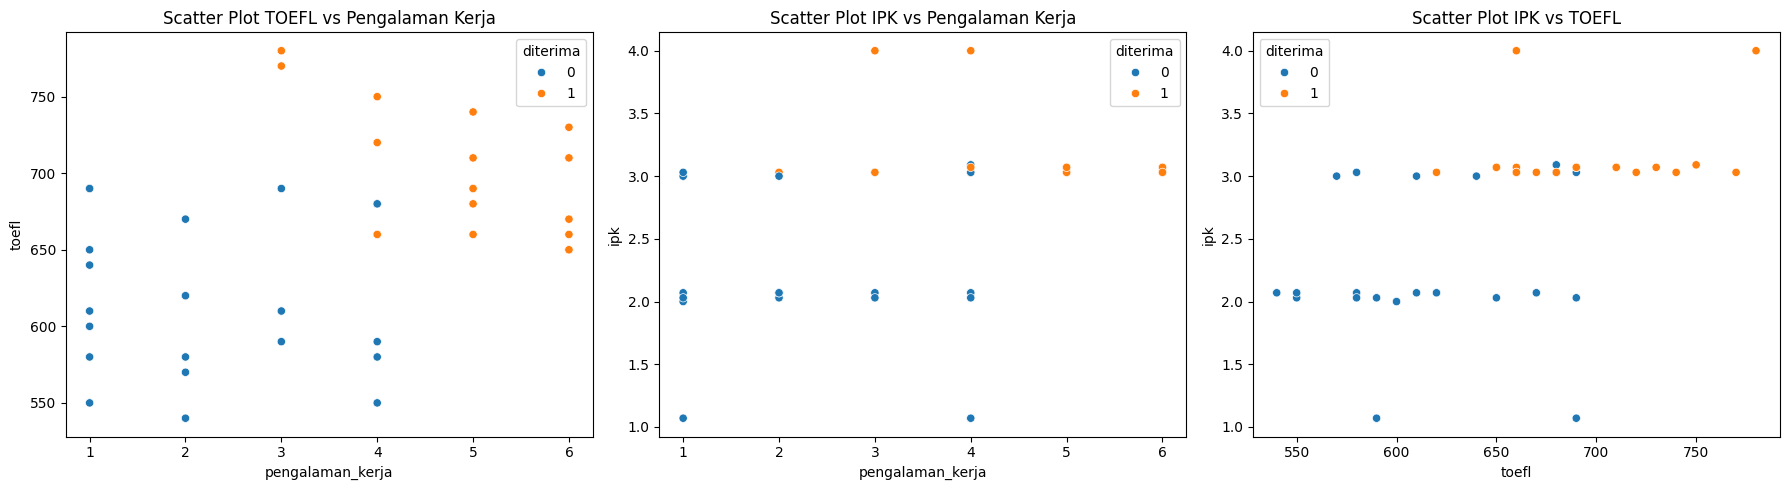

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=cpns, x='pengalaman_kerja', y='toefl', hue='diterima', ax=axes[0])
axes[0].set_title('Scatter Plot TOEFL vs Pengalaman Kerja')

sns.scatterplot(data=cpns, x='pengalaman_kerja', y='ipk', hue='diterima', ax=axes[1])
axes[1].set_title('Scatter Plot IPK vs Pengalaman Kerja')

sns.scatterplot(data=cpns, x='toefl', y='ipk', hue='diterima', ax=axes[2])
axes[2].set_title('Scatter Plot IPK vs TOEFL')

plt.tight_layout()
plt.show()

Dari grafik diatas terlihat kalau pelamar yang punya kombinasi skor TOEFL tinggi, IPK di atas 3.0, serta pengalaman kerja lebih lama berwarna orange yang artinya diterima di perusahaan.

# **C**

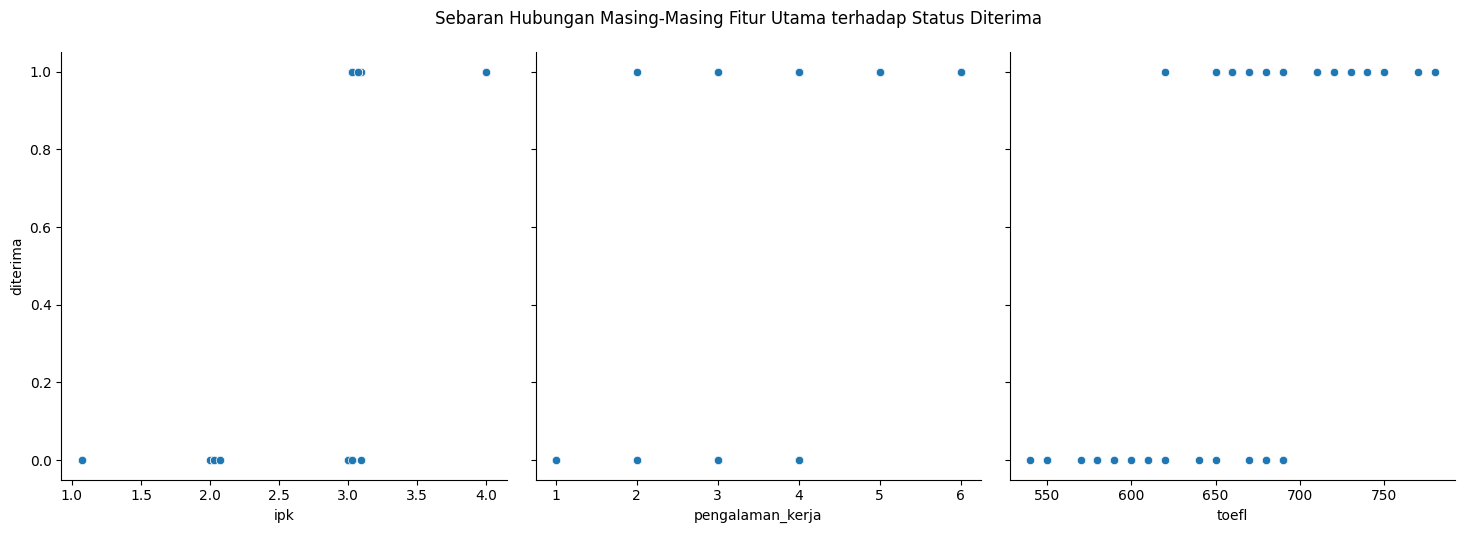

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.PairGrid(cpns,
                 x_vars=['ipk', 'pengalaman_kerja', 'toefl'],
                 y_vars=['diterima'],
                 height=5, aspect=1)
g.map(sns.scatterplot)

plt.suptitle('Sebaran Hubungan Masing-Masing Fitur Utama terhadap Status Diterima',
             y=1.05)
plt.show()

Hasil grafik diatas nunjukan bagaimana tiga faktor utama IPK, pengalaman kerja, dan skor TOEFL berhubungan dengan status diterima.  Dalam grafik menggambarkan kalau makin tinggi IPK, makin banyak peluang diterima, mempunyai  pengalaman kerja juga menjadi peluang lebih mudah diterima, dan skor TOEFL yang tinggi juga menjadi peluang untuk diterima.

# **D**

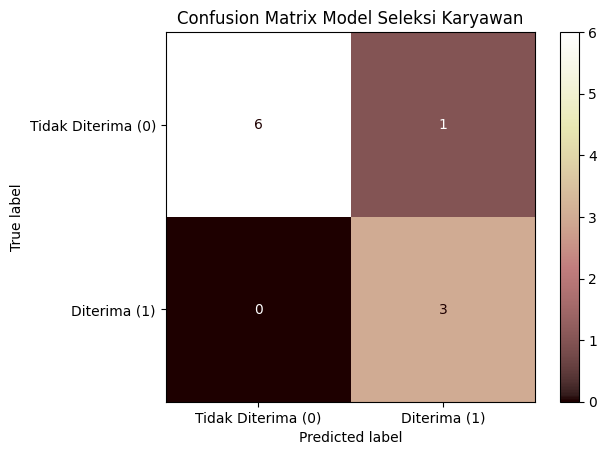

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = cpns[['toefl', 'ipk', 'pengalaman_kerja']]
y = cpns['diterima']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Diterima (0)', 'Diterima (1)'])
disp.plot(cmap='pink')
plt.title('Confusion Matrix Model Seleksi Karyawan')
plt.show()

Hasil di atas model berhasil memprediksi 6 orang tidak diterima dengan benar (true negative) dan 3 orang diterima dengan benar (true positive). Tapi 1 ada kesalahan prediksi di mana data asli tidak diterima tetapi diprediksi diterima (false positive).

In [ ]:
from tabulate import tabulate

df_analisis = X_test.copy()
df_analisis['diterima'] = y_test
df_analisis['Prediksi_Diterima'] = y_pred
print(tabulate(df_analisis, headers='keys', tablefmt='fancy_grid', showindex=True))

╒════╤═════════╤═══════╤════════════════════╤════════════╤═════════════════════╕
│    │   toefl │   ipk │   pengalaman_kerja │   diterima │   Prediksi_Diterima │
╞════╪═════════╪═══════╪════════════════════╪════════════╪═════════════════════╡
│ 19 │     590 │  2.03 │                  3 │          0 │                   0 │
├────┼─────────┼───────┼────────────────────┼────────────┼─────────────────────┤
│ 16 │     580 │  2.07 │                  4 │          0 │                   0 │
├────┼─────────┼───────┼────────────────────┼────────────┼─────────────────────┤
│ 15 │     610 │  3    │                  1 │          0 │                   0 │
├────┼─────────┼───────┼────────────────────┼────────────┼─────────────────────┤
│ 26 │     660 │  3.07 │                  4 │          1 │                   1 │
├────┼─────────┼───────┼────────────────────┼────────────┼─────────────────────┤
│  4 │     680 │  3.09 │                  4 │          0 │                   1 │
├────┼─────────┼───────┼────

In [ ]:
from tabulate import tabulate

df_baru = pd.DataFrame({
    'toefl': [590, 740, 680, 610, 710],
    'ipk': [2, 3.7, 3.3, 2.3, 3],
    'pengalaman_kerja': [3, 4, 6, 1, 5]
})

prediksi_baru = model.predict(df_baru)

df_baru['Status_Prediksi'] = ['Diterima' if p == 1 else 'Tidak Diterima' for p in prediksi_baru]

print("Hasil Prediksi Kelulusan Pelamar Baru:")
print(tabulate(df_baru, headers='keys', tablefmt='fancy_grid', showindex=True))

Hasil Prediksi Kelulusan Pelamar Baru:
╒════╤═════════╤═══════╤════════════════════╤═══════════════════╕
│    │   toefl │   ipk │   pengalaman_kerja │ Status_Prediksi   │
╞════╪═════════╪═══════╪════════════════════╪═══════════════════╡
│  0 │     590 │   2   │                  3 │ Tidak Diterima    │
├────┼─────────┼───────┼────────────────────┼───────────────────┤
│  1 │     740 │   3.7 │                  4 │ Diterima          │
├────┼─────────┼───────┼────────────────────┼───────────────────┤
│  2 │     680 │   3.3 │                  6 │ Diterima          │
├────┼─────────┼───────┼────────────────────┼───────────────────┤
│  3 │     610 │   2.3 │                  1 │ Tidak Diterima    │
├────┼─────────┼───────┼────────────────────┼───────────────────┤
│  4 │     710 │   3   │                  5 │ Diterima          │
╘════╧═════════╧═══════╧════════════════════╧═══════════════════╛
